In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
# -----------------------------
# Device
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [3]:
# -----------------------------
# Image Transformations
# -----------------------------

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])


In [5]:
# -----------------------------
# Load Dataset
# -----------------------------

train_dataset = datasets.ImageFolder(
    root= r"C:\Users\vicky\Desktop\8thsem_project\Dataset\Goat And Sheep\train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root= r"C:\Users\vicky\Desktop\8thsem_project\Dataset\Goat And Sheep\valid",
    transform=val_transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print("Classes:", train_dataset.classes)

Classes: ['Goat', 'Sheep']


In [6]:
# -----------------------------
# Load ConvNeXt Model
# -----------------------------

model = models.convnext_tiny(weights="DEFAULT")

# Replace classifier for 2 classes
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 2)

model = model.to(device)

In [7]:
# -----------------------------
# Loss and Optimizer
# -----------------------------

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


In [10]:
# -----------------------------
# Training Loop
# -----------------------------

epochs = 10

train_losses = []
val_accuracies = []

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # -----------------------------
    # Validation
    # -----------------------------

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs,1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}  Loss:{epoch_loss:.4f}  Val Acc:{accuracy:.2f}%")


Epoch 1/10  Loss:0.0248  Val Acc:98.46%
Epoch 2/10  Loss:0.0109  Val Acc:99.38%
Epoch 3/10  Loss:0.0042  Val Acc:98.46%
Epoch 4/10  Loss:0.0012  Val Acc:98.15%
Epoch 5/10  Loss:0.0074  Val Acc:97.85%
Epoch 6/10  Loss:0.0095  Val Acc:98.77%
Epoch 7/10  Loss:0.0191  Val Acc:98.77%
Epoch 8/10  Loss:0.0029  Val Acc:99.08%
Epoch 9/10  Loss:0.0010  Val Acc:99.08%
Epoch 10/10  Loss:0.0003  Val Acc:99.08%


In [11]:
# -----------------------------
# Save FULL MODEL
# -----------------------------

torch.save(model, "goat_sheep_model.pth")

print("Model saved as goat_sheep_model.pth")

Model saved as goat_sheep_model.pth


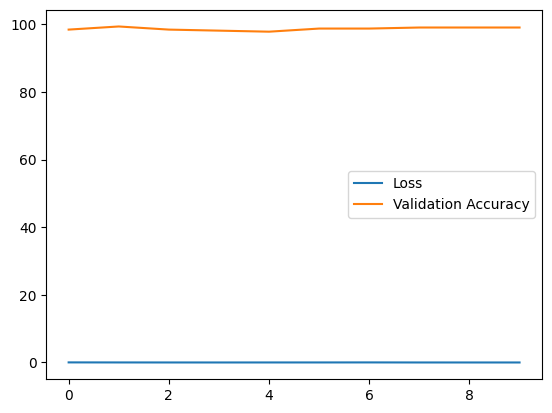

In [12]:
# -----------------------------
# Plot Training Graph
# -----------------------------

plt.plot(train_losses,label="Loss")
plt.plot(val_accuracies,label="Validation Accuracy")
plt.legend()
plt.show()